#**Pre-request**

##Mount google drive


In [1]:
### **Mount** Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install pakages


In [2]:
#Install pakages
project_path = "/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/"
!cat "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt"
!pip install  -r "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt" --no-cache-dir
%cd $project_path





torch
transformers
huggingface_hub
datasets
timm
patool
sktime
reformer_pytorch
optuna
ptflopsRequirement already satisfied: torch in /usr/local/lib/python3.12/dist-packages (from -r /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/requirement/Install/NASEnhancedPretraindMLModleAdvance.txt (line 1)) (2.11.0+cu128)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 387.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 415.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 409.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 396.2 MB/s eta 0:00:00
/content/drive/MyDrive/Sem-6/coding/github/fraud_detection


##Import  libs

In [3]:
# =====================================================
# ⏱️ Runtime & System Utilities
# =====================================================
import os
import sys
import time
import logging
import hashlib
import shutil
import subprocess
import warnings
from datetime import datetime
from argparse import Namespace

# Start timer
start_time = time.time()

# =====================================================
# 📦 Core Data Handling
# =====================================================
import numpy as np
import pandas as pd
import yaml

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# =====================================================
# 📊 Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# ⚙️ Machine Learning (Scikit-learn)
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    cohen_kappa_score
)

# =====================================================
# 🌲 Gradient Boosting
# =====================================================
from xgboost import XGBClassifier
import joblib

# =====================================================
# 🔥 Deep Learning (PyTorch)
# =====================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast
from torch.utils.flop_counter import FlopCounterMode

# =====================================================
# 🧠 Deep Learning (TensorFlow / Keras)
# =====================================================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout, Layer
from tensorflow.keras.optimizers import Adam

# =====================================================
# 🤗 Transformers & Time Series
# =====================================================
from transformers import AutoModel
from sktime.datasets import load_from_tsfile_to_dataframe

# =====================================================
# 📈 Model Complexity / FLOPs
# =====================================================
from ptflops import get_model_complexity_info

# =====================================================
# 📊 Data Pipeline (Custom)
# =====================================================
sys.path.append('/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library')

from models.TimesNet import Model as TimesNetModel
from data_provider.data_factory import data_provider

# =====================================================
# 🧠 Explainability
# =====================================================
import shap

# =====================================================
# 📊 Utilities & Progress
# =====================================================
from tqdm import tqdm

# =====================================================
# 📊 Google Colab (Optional)
# =====================================================
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    data_table.DataTable.max_columns = 50
    data_table.DataTable.max_rows = 150
except ImportError:
    pass

# =====================================================
# ✅ Ready
# =====================================================
print("✅ All imports loaded successfully!")

✅ All imports loaded successfully!


##Confirmation setup

In [4]:
# =====================================================
# 🎲 Random Seeds (Reproducibility)
# =====================================================
!nvidia-smi                # confirm GPU
!pip show torch  # confirm versions
torch.manual_seed(7)
np.random.seed(7)

Sat Jul 11 04:36:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Read Config file

In [5]:

logger = logging.getLogger(__name__)

def load_config(config_path="configs/baseline.yaml"):
    """Load YAML config file and expand ${root_path} placeholders."""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    logger.info(f"✅ Loaded config from {config_path}")

    # --- Expand ${root_path} placeholders ---
    root = config.get("root_path", "")

    def expand_paths(obj):
        if isinstance(obj, dict):
            return {k: expand_paths(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [expand_paths(i) for i in obj]
        elif isinstance(obj, str) and "${root_path}" in obj:
            return obj.replace("${root_path}", root)
        else:
            return obj

    config = expand_paths(config)
    return config
config = load_config(os.path.join(project_path, "configs", "baseline.yaml"))


## Set Variables

In [6]:
max_seq_len = 4                  # Maximum sequence length
recent_mode = False               # False → oldest mode, True → recent-window mode
# n_jobs=-1
num_classes = 2                   # Binary classification
epochs = 20                       # Maximum training epochs

# ----------------------------------------------------------
# 📊 Evaluation Settings
# ----------------------------------------------------------
correlation_threshold = 0.85      # Feature correlation threshold

# ----------------------------------------------------------
# 📈 Progressive Evaluation
# ----------------------------------------------------------
method = "linear"                 # Interpolation method for key_rounds
n_points = 10                     # Number of evaluation points

# ----------------------------------------------------------
# 💾 Paths
# ----------------------------------------------------------
model_path = config['ML']['models']

# ==========================================================
# ✅ Configuration Summary
# ==========================================================
print("="*60)
print("📋 CONFIGURATION SUMMARY")
print("="*60)
print(f"  Sequence length:  {max_seq_len}")
print(f"  Mode:             {'Recent' if recent_mode else 'Oldest'}")
print(f"  Model path:       {model_path}")
print("="*60)

# Global unified results table for all models
results_table = pd.DataFrame(columns=["NAS SL", "Testing SL","Model","F1", "AUC", "Recall","Precision" ,"threshold","Round"])
summary = pd.DataFrame(
    columns=[
        "NAS SL",
        "Testing SL",
        "Model",
        "F1",
        "AUC",
        "Recall",
        "Precision",
        "threshold"
    ]
)


📋 CONFIGURATION SUMMARY
  Sequence length:  4
  Mode:             Oldest
  Model path:       /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/


##Models Paramters

In [7]:
# ==================================================
# Base_SL = 4
# ==================================================

Base_SL = 'S4'

timesnet_parameters = {
    "learning_rate": 0.0017898065289489,
    "d_model":       128,
    "d_ff":          8,
    "e_layers":      2,
    "top_k":         2,
    "dropout":       0.3193293820708461,
    "batch_size":    16,
    "patience":      5,
    "num_kernels":   6,
}

lstm_parameters = {
    "learning_rate": 0.0017753464688148,
    "d_model":       64,
    "d_ff":          64,
    "e_layers":      2,
    "dropout":       0.2638015575935464,
    "batch_size":    8,
    "patience":      5,
}

transformer_parameters = {
    "learning_rate": 0.0004870572269026,
    "d_model":       16,
    "n_heads":       8,
    "d_ff":          64,
    "e_layers":      3,
    "dropout":       0.01151767389306,
    "batch_size":    8,
    "patience":      2,
}

xgb_parameters = {
    "n_estimators":     64,
    "max_depth":        5,
    "learning_rate":    0.0723030625307496,
    "subsample":        0.6123089352692415,
    "colsample_bytree": 0.5264109400254153,
    "min_child_weight": 2,
    "gamma":            0.9997880756517732,
    "patience":         2,
    "eval_metric":      "logloss",
}

rf_parameters = {
    "n_estimators":      241,
    "max_depth":         9,
    "min_samples_split": 13,
    "min_samples_leaf":  1,
}




In [8]:

# ✅ Unpack timesnet_parameters into simple variables for shell script
_tn_patience      = timesnet_parameters["patience"]
_tn_batch_size    = timesnet_parameters["batch_size"]
_tn_learning_rate = timesnet_parameters["learning_rate"]
_tn_e_layers      = timesnet_parameters["e_layers"]
_tn_d_model       = timesnet_parameters["d_model"]
_tn_d_ff          = timesnet_parameters["d_ff"]
_tn_top_k         = timesnet_parameters["top_k"]
_tn_dropout       = timesnet_parameters["dropout"]
_tn_num_kernels = timesnet_parameters["num_kernels"]


## Helpers

In [9]:
RESULTS_OUT = os.path.join(config["root_path"], "results", "Consolidated_v2")
os.makedirs(RESULTS_OUT, exist_ok=True)

def append_to_summary(summary, model_name, results):
    """
    Appends or updates the summary table with model results.
    Works with both capitalized and lowercase keys automatically.
    """
    # ✅ Create summary DataFrame if missing
    if summary is None or not isinstance(summary, pd.DataFrame):
          summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])
    # Ensure "Model" column exists (prevents KeyError)
    if "Model" not in summary.columns:
        summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])

    # ✅ Normalize key names to lowercase
    results = {k.lower(): v for k, v in results.items()}

    # ✅ Remove any existing row for the same model
    summary = summary[summary["Model"] != model_name]

    # ✅ Add new row (robust to missing values)
    row = {
        "NAS SL":Base_SL,
        "Testing SL": max_seq_len,
        "Model": model_name,
        "F1": round(results.get("f1", np.nan), 4) if not pd.isna(results.get("f1", np.nan)) else np.nan,
        "AUC": round(results.get("auc", np.nan), 4) if not pd.isna(results.get("auc", np.nan)) else np.nan,
        "Recall": round(results.get("recall", np.nan), 4) if not pd.isna(results.get("recall", np.nan)) else np.nan,
        "Precision": round(results.get("precision", np.nan), 4) if not pd.isna(results.get("precision", np.nan)) else np.nan,
        "Threshold": round(results.get("threshold", np.nan), 4) if not pd.isna(results.get("threshold", np.nan)) else np.nan
    }


    # ✅ Append and reindex
    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = summary.reindex(columns=["NAS SL","Testing SL","Model","F1", "AUC", "Recall", "Precision",  "Threshold"])
    return summary

def plot_feature_importance(model, X_train, model_name="Model", top_n=20):
    """
    Plot feature importance for tree-based models (XGBoost, RandomForest).
    """


    # Handle model type
    if hasattr(model, "get_booster"):  # XGBoost
        importance = model.get_booster().get_score(importance_type='gain')
        fi = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        })
    elif hasattr(model, "feature_importances_"):  # RandomForest
        fi = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_
        })
    else:
        raise ValueError(f"{model_name} does not support feature importance extraction.")

    # Sort and plot
    fi = fi.sort_values(by='Importance', ascending=False)
    display(fi.head(10))

    plt.figure(figsize=(10,6))
    plt.barh(fi['Feature'][:top_n][::-1], fi['Importance'][:top_n][::-1])
    plt.title(f'📊 {model_name} Feature Importance (Top {top_n})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    return fi




def find_best_threshold(y_true, probs, low=0.2, high=0.8, n=61):
    best_f1 = -1.0
    best_thr = 0.5
    for thr in np.linspace(low, high, n):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1


# ============================================================
# Second operating point: F2 (recall-weighted), validation-only
# ============================================================
from sklearn.metrics import fbeta_score

op2_table = pd.DataFrame(columns=[
    "Model", "Threshold_F1", "Threshold_F2", "Val_F2",
    "Test_F1_at_F2", "Test_Recall_at_F2", "Test_Precision_at_F2"])

def find_best_threshold_f2(y_true, probs, low=0.2, high=0.8, n=61, beta=2.0):
    best_fb, best_thr = -1.0, 0.5
    for thr in np.linspace(low, high, n):
        fb = fbeta_score(y_true, (probs >= thr).astype(int), beta=beta, zero_division=0)
        if fb > best_fb:
            best_fb, best_thr = fb, thr
    return best_thr, best_fb

def append_op2(op2_table, model_name, y_val, val_probs, y_test, test_probs, thr_f1):
    thr_f2, val_f2 = find_best_threshold_f2(y_val, val_probs)
    preds = (test_probs >= thr_f2).astype(int)
    row = {"Model": model_name, "Threshold_F1": round(thr_f1, 2),
           "Threshold_F2": round(thr_f2, 2), "Val_F2": round(val_f2, 4),
           "Test_F1_at_F2": round(f1_score(y_test, preds, zero_division=0), 4),
           "Test_Recall_at_F2": round(recall_score(y_test, preds, zero_division=0), 4),
           "Test_Precision_at_F2": round(precision_score(y_test, preds, zero_division=0), 4)}
    print(f"  🎯 {model_name}: thr_F1={thr_f1:.2f} → thr_F2={thr_f2:.2f} | "
          f"test recall {row['Test_Recall_at_F2']:.4f} / precision {row['Test_Precision_at_F2']:.4f}")
    return pd.concat([op2_table, pd.DataFrame([row])], ignore_index=True)

def plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col=None,
    figsize=(14, 6)
):
    """
    Plot progressive evaluation metrics per round for multiple models.

    Parameters
    ----------
    results_table : pd.DataFrame
        Must contain columns: Model, metrics, and either Round or input_size
    metrics : tuple
        Metrics to plot (default: AUC, Recall, F1)
    round_col : str or None
        Column name for x-axis. If None, auto-detects.
    figsize : tuple
        Figure size for plots
    """

    # --------------------------------------------------
    # Auto-detect round column
    # --------------------------------------------------
    if round_col is None:
        if "Round" in results_table.columns:
            round_col = "Round"
        elif "input_size" in results_table.columns:
            round_col = "input_size"
        else:
            raise ValueError("No Round or input_size column found.")

    # --------------------------------------------------
    # Sort results (important for correct curves)
    # --------------------------------------------------
    results_table = results_table.sort_values(
        by=[round_col, "Model"],
        ascending=True
    ).reset_index(drop=True)


    # --------------------------------------------------
    # Plot each metric
    # --------------------------------------------------
    for metric in metrics:

        plt.figure(figsize=figsize)

        for model in results_table["Model"].unique():
            subset = (
                results_table[results_table["Model"] == model]
                .sort_values(by=round_col)
            )

            plt.plot(
                subset[round_col],
                subset[metric],
                marker="o",
                markersize=6,
                linewidth=2,
                label=model,
                alpha=0.85
            )

        plt.title(f"{metric} per {round_col}", fontsize=18)
        plt.xlabel(round_col, fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.4)

        # Legend outside
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncol=4,
            fontsize=10
        )

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        plt.show()
    display(results_table)

    return results_table

# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

def get_key_rounds(max_seq_len, method="linear", n_points=5):
    """
    Generate scientifically meaningful evaluation checkpoints.

    Args:
        max_seq_len: Maximum sequence length (16, 100, 300, etc.)
        method: Selection strategy
            - "linear": Equal spacing (1, 25%, 50%, 75%, 100%)
            - "logarithmic": More points early (where changes happen fast)
            - "sqrt": Square root spacing (balanced)
            - "percentile": Fixed percentages
        n_points: Number of evaluation points (default 5)

    Returns:
        List of round numbers to evaluate
    """

    if max_seq_len <= n_points:
        # If sequence is short, evaluate all rounds
        return list(range(1, max_seq_len + 1))

    if method == "linear":
        # Equal spacing: 1, 25%, 50%, 75%, 100%
        rounds = np.linspace(1, max_seq_len, n_points)

    elif method == "logarithmic":
        # More points early (fraud detection often shows early signal)
        # Log scale: 1, 2, 4, 8, 16 style
        rounds = np.logspace(0, np.log10(max_seq_len), n_points)

    elif method == "sqrt":
        # Square root spacing (balanced between linear and log)
        rounds = np.square(np.linspace(1, np.sqrt(max_seq_len), n_points))

    elif method == "percentile":
        # Fixed percentages: 1st event, 10%, 25%, 50%, 75%, 100%
        percentages = [0, 0.1, 0.25, 0.5, 0.75, 1.0]
        rounds = [max(1, int(p * max_seq_len)) for p in percentages]
        return sorted(set(rounds))  # Remove duplicates

    elif method == "early_focus":
        # Focus on early detection (more points in first half)
        # Useful for fraud detection where early signal matters
        early = np.linspace(1, max_seq_len * 0.5, n_points - 2)
        late = [max_seq_len * 0.75, max_seq_len]
        rounds = np.concatenate([early, late])

    else:
        raise ValueError(f"Unknown method: {method}")

    # Convert to integers, ensure valid range, remove duplicates
    rounds = [int(round(r)) for r in rounds]
    rounds = [max(1, min(r, max_seq_len)) for r in rounds]
    rounds = sorted(set(rounds))

    # Always include 1 and max_seq_len
    if 1 not in rounds:
        rounds = [1] + rounds
    if max_seq_len not in rounds:
        rounds = rounds + [max_seq_len]

    return rounds


# ============================================================
# General Metric + Gap Helpers
# ============================================================


def get_timesnet_val_threshold(results_dir):
    val_prob_path = os.path.join(results_dir, "val_prob.npy")
    val_true_path = os.path.join(results_dir, "val_true.npy")

    if not os.path.exists(val_prob_path) or not os.path.exists(val_true_path):
        raise FileNotFoundError(
            f"Missing validation probability files in {results_dir}. "
            f"Expected val_prob.npy and val_true.npy"
        )

    val_probs = np.load(val_prob_path)
    val_true = np.load(val_true_path)

    best_thr, best_f1 = find_best_threshold(val_true, val_probs)
    return best_thr, best_f1


gap_table = pd.DataFrame(columns=[
    "Model",
    "Train_F1", "Val_F1", "Test_F1",
    "Train_vs_Val_Gap",
    "Train_vs_Test_Gap",
    "Val_vs_Test_Gap",
    "Threshold"
])

def evaluate_probs(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "F1": f1_score(y_true, preds, zero_division=0),
        "AUC": roc_auc_score(y_true, probs),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "Precision": precision_score(y_true, preds, zero_division=0)
    }

def append_gap_result(gap_table, model_name, train_f1, val_f1, test_f1, threshold):
    row = {
        "Model": model_name,
        "Train_F1": round(train_f1, 4),
        "Val_F1": round(val_f1, 4),
        "Test_F1": round(test_f1, 4),
        "Train_vs_Val_Gap": round(train_f1 - val_f1, 4),
        "Train_vs_Test_Gap": round(train_f1 - test_f1, 4),
        "Val_vs_Test_Gap": round(val_f1 - test_f1, 4),
        "Threshold": round(threshold, 4)
    }

    gap_table = gap_table[gap_table["Model"] != model_name]
    gap_table = pd.concat([gap_table, pd.DataFrame([row])], ignore_index=True)
    return gap_table

def plot_probability_distribution(model_name, val_probs, test_probs, threshold, debug=True):
    val_probs = np.asarray(val_probs).flatten()
    test_probs = np.asarray(test_probs).flatten()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(val_probs, bins=50, alpha=0.7)
    plt.axvline(threshold, linestyle="--", label=f"Threshold={threshold:.2f}")
    plt.title(f"{model_name} Validation Probability")
    plt.xlabel("Fraud Probability")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(test_probs, bins=50, alpha=0.7)
    plt.axvline(threshold, linestyle="--", label=f"Threshold={threshold:.2f}")
    plt.title(f"{model_name} Test Probability")
    plt.xlabel("Fraud Probability")
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

def print_detailed_report(model_name, y_true, y_pred):
    print("\n" + "="*60)
    print(f"📊 Detailed Report: {model_name}")
    print("="*60)
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Fraud"],
        digits=4,
        zero_division=0
    ))

## Drop and select features

In [10]:
# def prepare_features(df):
#     """
#     Selects only the explicitly defined features for model training.
#     You control which features are used by editing 'selected_features' below.
#     """

#     # --- Define selected features manually ---
#     selected_features = [
#         "window_size", "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
#        "voc_avg_duration", "voc_max_duration", "voc_std_duration", "voc_active_days",
#        "voc_active_hours", "sms_total_msgs", "sms_unique_contacts", "sms_active_hours",
#        "sms_calltype_ratio", "app_months_active", "app_total_flow", "app_avg_flow",
#        "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max", "user_months_active",
#         "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt", "snapshot_round"
#    ]

#     # --- Keep only existing columns ---
#     available = [f for f in selected_features if f in df.columns]
#     missing = [f for f in selected_features if f not in df.columns]

#     X = df[available].copy()

#     #print(f"\n📊 Final features used ({len(available)}): {available}")
#     if missing:
#         print(f"⚠️ Missing columns not found in data: {missing}")

#     return X


## Key Rounds

In [11]:
# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

key_rounds = get_key_rounds(max_seq_len, method=method, n_points=n_points)
print(f"📊 Evaluating rounds: {key_rounds}")
print(f"   Total: {len(key_rounds)} rounds instead of {max_seq_len}")

📊 Evaluating rounds: [1, 2, 3, 4]
   Total: 4 rounds instead of 4


#ML Modules

### Load

In [12]:
def load_raw_datasets(config):


    if "ML" in config and "Events" in config["ML"]:
        events_cfg = config["ML"]["Events"]
    else:
        events_cfg = config["Events"]

    base = events_cfg["base_path"]
    files = events_cfg["files"]

    # --- Load all datasets ---
    df_voc = pd.read_csv(os.path.join(base, files["voc"]))
    df_sms = pd.read_csv(os.path.join(base, files["sms"]))
    df_app = pd.read_csv(os.path.join(base, files["app"]))
    df_user = pd.read_csv(os.path.join(base, files["user"]))

    # --- Normalize timestamps and add source column ---
    for df, src in [(df_voc, "VOC"), (df_sms, "SMS"), (df_app, "APP"), (df_user, "USER")]:
        df["source"] = src
        ts_col = [c for c in df.columns if "time" in c.lower()][0]
        df.rename(columns={ts_col: "event_time"}, inplace=True)
        df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

    print("✅ Raw datasets loaded and timestamp-normalized.")
    return df_voc, df_sms, df_app, df_user

df_voc, df_sms, df_app, df_user = load_raw_datasets(config)


✅ Raw datasets loaded and timestamp-normalized.


### Build timeline (events)

In [13]:
def merge_and_prepare_events(df_voc, df_sms, df_app, df_user):

    # --- 1️⃣ Normalize USER dataset ---
    if 'label' not in df_user.columns:
        raise KeyError("❌ 'label' column not found in user dataset")

    # Ensure numeric consistency
    df_user['label'] = df_user['label'].fillna(0).astype(int)
    df_user['idcard_cnt'] = df_user['idcard_cnt'].fillna(0).astype(float)
    df_user['arpu_value'] = df_user['arpu_value'].fillna(0).astype(float)

    # --- 2️⃣ Extract static info for merging (label + sim count only) ---
    #static_user_info = df_user.groupby("phone_no_m", as_index=False)[["label", "idcard_cnt"]].max()
    # --- 2️⃣ Extract static info from the RAW user table (covers all 6,106 users) ---
    lbl_cfg = config["ML"]["labels"]
    raw_user = pd.read_csv(os.path.join(lbl_cfg["base_path"], lbl_cfg["file"]))
    static_user_info = raw_user[["phone_no_m", "label", "idcard_cnt"]].drop_duplicates("phone_no_m")
    static_user_info["label"] = static_user_info["label"].astype(int)
    static_user_info["idcard_cnt"] = static_user_info["idcard_cnt"].fillna(0).astype(float)

    # --- 3️⃣ Merge static info into other event tables ---
    df_voc = df_voc.merge(static_user_info, on="phone_no_m", how="left")
    df_sms = df_sms.merge(static_user_info, on="phone_no_m", how="left")
    df_app = df_app.merge(static_user_info, on="phone_no_m", how="left")


    # --- 4️⃣ Combine all transactional event sources ---
    # include df_user itself since arpu_value is event-like
    events = pd.concat([df_voc, df_sms, df_app, df_user], ignore_index=True)

    # --- 5️⃣ Fill and order ---
    #events["label"] = events["label"].fillna(0).astype(int)
    missing = int(events["label"].isna().sum())
    assert missing == 0, f"{missing} events have no label — label merge is broken"
    events["label"] = events["label"].astype(int)

    events["event_time"] = pd.to_datetime(events["event_time"], errors="coerce")
    events = events.sort_values(["phone_no_m", "event_time"]).reset_index(drop=True)

    # --- 6️⃣ Summary ---
    print("\n🔎 Feature Summary per Source:")
    for src, df in [("VOC", df_voc), ("SMS", df_sms), ("APP", df_app), ("USER", df_user)]:
        print(f"\n📂 Source: {src}")
        print(f"   Events: {len(df):,}")
        print(f"   Users : {df['phone_no_m'].nunique():,}")
        print(f"   Columns ({len(df.columns)}): {', '.join(df.columns)}")

    print("\n📊 Combined Dataset Summary:")
    print(f"   Total events: {len(events):,}")
    print(f"   Unique users: {events['phone_no_m'].nunique():,}")
    print(f"   Fraud ratio: {events['label'].mean()*100:.2f}%")
    user_labels = events.groupby("phone_no_m")["label"].max()
    print(f"   Fraud users: {int(user_labels.sum()):,} / {user_labels.size:,} ({user_labels.mean()*100:.2f}%)")

    return events

events = merge_and_prepare_events(df_voc, df_sms, df_app, df_user)

display(events.head())


🔎 Feature Summary per Source:

📂 Source: VOC
   Events: 5,015,430
   Users : 6,025
   Columns (11): phone_no_m, opposite_no_m, calltype_id, event_time, call_dur, city_name, county_name, imei_m, source, label, idcard_cnt

📂 Source: SMS
   Events: 6,848,509
   Users : 6,103
   Columns (7): phone_no_m, opposite_no_m, calltype_id, event_time, source, label, idcard_cnt

📂 Source: APP
   Events: 3,283,602
   Users : 6,106
   Columns (10): phone_no_m, event_time, source, busi_name, flow, month_id, flow_norm, month_str, label, idcard_cnt

📂 Source: USER
   Events: 39,454
   Users : 5,929
   Columns (10): phone_no_m, event_time, source, month_id, arpu_value, city_name, county_name, idcard_cnt, label, month_col

📊 Combined Dataset Summary:
   Total events: 15,186,995
   Unique users: 6,106
   Fraud ratio: 24.63%
   Fraud users: 1,962 / 6,106 (32.13%)


,phone_no_m,opposite_no_m,calltype_id,event_time,call_dur,city_name,county_name,imei_m,source,label,idcard_cnt,busi_name,flow,month_id,flow_norm,month_str,arpu_value,month_col
0,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Split data based on users (fraud, not fraud)

In [14]:


# ======================================
# Clean Numeric Columns
# ======================================
events = events.copy()
numeric_cols = events.select_dtypes(include=["number"]).columns.difference(["label"])

# Replace NaN with 0 for numeric fields (avoids scaling issues)
events[numeric_cols] = events[numeric_cols].fillna(0)

print(f"\n📊 Numeric columns to scale ({len(numeric_cols)}): {numeric_cols.tolist()}")


# ======================================
# 2 Create / Load Shared Train-Val-Test User Split
# ======================================
split_dir = os.path.join(config["root_path"], "splits", "shared_user_split_v1")
train_split_file = f"{split_dir}/train_users.csv"
test_split_file  = f"{split_dir}/test_users.csv"
val_split_file   = f"{split_dir}/val_users.csv"

os.makedirs(split_dir, exist_ok=True)

all_split_files_exist = (
    os.path.exists(train_split_file)
    and os.path.exists(test_split_file)
    and os.path.exists(val_split_file)
)

if all_split_files_exist:
    print("📂 Using shared user split files...")
    train_users = set(pd.read_csv(train_split_file)["phone_no_m"])
    test_users  = set(pd.read_csv(test_split_file)["phone_no_m"])
    val_users   = set(pd.read_csv(val_split_file)["phone_no_m"])
else:
    print("🆕 Creating shared train/test/val user split...")

    # One label per user
    user_labels = events.groupby("phone_no_m")["label"].max()
    fraud_users = user_labels[user_labels == 1].index
    normal_users = user_labels[user_labels == 0].index

    # 1) Train/Test split (split fraud user %)
    fraud_train, fraud_test = train_test_split(
        fraud_users, test_size=0.2, random_state=42
    )
    normal_train, normal_test = train_test_split(
        normal_users, test_size=0.2, random_state=42
    )

    train_users_full = set(fraud_train) | set(normal_train)
    test_users = set(fraud_test) | set(normal_test)

    # 2) Validation split from training users only
    train_user_labels = user_labels.loc[list(train_users_full)]

    fraud_train_users = train_user_labels[train_user_labels == 1].index
    normal_train_users = train_user_labels[train_user_labels == 0].index

    fraud_tr, fraud_val = train_test_split(
        fraud_train_users, test_size=0.2, random_state=42
    )
    normal_tr, normal_val = train_test_split(
        normal_train_users, test_size=0.2, random_state=42
    )

    train_users = set(fraud_tr) | set(normal_tr)
    val_users   = set(fraud_val) | set(normal_val)

    pd.DataFrame({"phone_no_m": sorted(train_users)}).to_csv(train_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(test_users)}).to_csv(test_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(val_users)}).to_csv(val_split_file, index=False)

    print(f"✅ Saved shared split files to '{split_dir}/'")
# ======================================
# Split overlap checks
# ======================================
assert len(train_users & test_users) == 0, "❌ User leakage: train and test overlap"
assert len(train_users & val_users) == 0, "❌ User leakage: train and val overlap"
assert len(test_users & val_users) == 0, "❌ User leakage: test and val overlap"

print("🔒 Split overlap checks passed:")
print(f"   train ∩ test = {len(train_users & test_users)}")
print(f"   train ∩ val  = {len(train_users & val_users)}")
print(f"   test  ∩ val  = {len(test_users & val_users)}")
user_labels = events.groupby("phone_no_m")["label"].max()
print(f"   sizes  train/val/test = {len(train_users)} / {len(val_users)} / {len(test_users)}")
print(f"   fraud  train/val/test = {int(user_labels.loc[list(train_users)].sum())} / "
      f"{int(user_labels.loc[list(val_users)].sum())} / {int(user_labels.loc[list(test_users)].sum())}")
# ======================================
# Apply Split to Events
# ======================================
train_events = events[events["phone_no_m"].isin(train_users)]
test_events  = events[events["phone_no_m"].isin(test_users)]
val_events = events[events["phone_no_m"].isin(val_users)]

# Sanity checks
assert len(set(train_events["phone_no_m"]) & set(test_events["phone_no_m"])) == 0, "❌ User leakage detected!"
assert train_events["label"].nunique() == 2, "❌ Training set must contain both classes"
assert test_events["label"].nunique() == 2, "❌ Test set must contain both classes"


📊 Numeric columns to scale (6): ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt']
📂 Using shared user split files...
🔒 Split overlap checks passed:
   train ∩ test = 0
   train ∩ val  = 0
   test  ∩ val  = 0
   sizes  train/val/test = 3907 / 977 / 1222
   fraud  train/val/test = 1255 / 314 / 393


### Add hour

In [15]:

#for all 3 dataset
for name, df in [
    ('train_events', train_events),
    ('val_events', val_events),
    ('test_events', test_events)
]:
    df = df.copy()
    df['event_time'] = pd.to_datetime(df['event_time'])#Ensures time is in correct format
    df = df.sort_values(['phone_no_m', 'event_time'], kind='mergesort').reset_index(drop=True)#Each user's events are in chronological order
    df['dt_hours'] = df.groupby('phone_no_m')['event_time'].diff().dt.total_seconds() / 3600#Time gap between consecutive events per user and convert to hours
    df['dt_hours'] = df['dt_hours'].fillna(0)#First event has no previous event → set to 0
    df['dt_hours'] = np.log1p(df['dt_hours']) #Apply log transformation , Highly skewed (many small gaps, few very large gaps)

    #Saves processed version back
    if name == 'train_events':
        train_events = df
    elif name == 'val_events':
        val_events = df
    else:
        test_events = df

#copy event to be used for snapshot based orgianl events
train_events_unscaled = train_events.copy()
test_events_unscaled = test_events.copy()
val_events_unscaled = val_events.copy()




# ▶  Advance ML

### Scale for DL

In [16]:

#Scale
#scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label"})
scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label", "source_id"})
scaler_seq = StandardScaler().fit(train_events[scale_cols_seq])
#Training data only to be used for calc the scaler
train_events[scale_cols_seq] = scaler_seq.transform(train_events[scale_cols_seq])
test_events[scale_cols_seq]  = scaler_seq.transform(test_events[scale_cols_seq])
val_events[scale_cols_seq]   = scaler_seq.transform(val_events[scale_cols_seq])

# ======================================
# Create Sequences (using multiple features)
# ======================================
numeric_features = [c for c in numeric_cols if c not in ["label"]]  # exclude label

#add dt_hours
if 'dt_hours' in train_events.columns:
    numeric_features.append('dt_hours')

print(f"\n📦 Features used for sequences: {numeric_features}")
feature_cols_tf = numeric_features.copy()

#add source_id
if "source_id" not in feature_cols_tf:
    feature_cols_tf.append("source_id")

print("[Transformer] feature_cols_tf:", feature_cols_tf)


📦 Features used for sequences: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours']
[Transformer] feature_cols_tf: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours', 'source_id']


### make_user_sequences

In [17]:

# ============================================================
# 2️⃣ Selector functions (FIXED, SIMPLE)
# ============================================================

def selector_oldest(r):
    """Select oldest r events"""
    return lambda df_u: df_u.head(r)

# def selector_last_r(r):
#     """Select LAST r events (to match full evaluation behavior)"""
#     return lambda df_u: df_u.tail(r)

# def selector_most_recent(r):
#     """Select most recent r events (used AFTER window freeze)"""
#     return lambda df_u: df_u.tail(r)

def make_user_sequences(
    events,
    feature_cols=None,
    max_seq_len=100,
    event_selector=None,
):
    events = events.copy()
    users, X_seq, y = [], [], []

    # le = LabelEncoder()
    # events["source_id"] = le.fit_transform(events["source"].astype(str))
    SOURCE_MAP = {
        "APP": 0,
        "SMS": 1,
        "USER": 2,
        "VOC": 3,
    }

    unknown_sources = set(events["source"].astype(str).unique()) - set(SOURCE_MAP.keys())
    assert len(unknown_sources) == 0, f"❌ Unknown source values found: {unknown_sources}"

    events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    if feature_cols is None:
        feature_cols = events.select_dtypes(include=["number"]) \
                             .columns.difference(["label"]) \
                             .tolist()
    if "source_id" not in feature_cols:
        feature_cols.append("source_id")

    for user, df_u in events.groupby("phone_no_m"):

        # 1️⃣ Sort
        df_u = df_u.sort_values("event_time")

        # 2️⃣ Freeze to last max_seq_len
        if recent_mode:
            df_u = df_u.tail(max_seq_len)   # E51..E100

        # 3️⃣ 🔁 APPLY PROGRESSIVE SELECTION HERE
        if event_selector is not None:
            df_u = event_selector(df_u)

        # 4️⃣ Features
        feats = df_u[feature_cols].to_numpy(dtype=float)

        # 5️⃣ Pad / truncate
        if len(feats) < max_seq_len:
            feats = np.pad(feats, ((max_seq_len - len(feats), 0), (0, 0)))
        else:
            feats = feats[-max_seq_len:]

        label = int(df_u["label"].max())

        X_seq.append(feats)
        y.append(label)
        users.append(user)

    return np.array(X_seq), np.array(y), np.array(users)



### Create sequences

In [18]:

trans_X_train, trans_y_train, users_train = make_user_sequences(train_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_test, trans_y_test, users_test = make_user_sequences(test_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_val, trans_y_val, _ =            make_user_sequences(val_events,    feature_cols=numeric_features,max_seq_len=max_seq_len, event_selector=selector_oldest(max_seq_len))
assert len(set(val_events["phone_no_m"])) > 0, "❌ Validation set is empty!"
assert val_events["label"].nunique() == 2, "❌ Validation set must contain both classes"

print("\n✅ Sequence Summary (per-user sequences):")
print(f"   X_train: {trans_X_train.shape} | Fraud ratio: {np.mean(trans_y_train)*100:.2f}%")
print(f"   X_test : {trans_X_test.shape} | Fraud ratio: {np.mean(trans_y_test)*100:.2f}%")

# ======================================
# Consistency Check
# ======================================
trans_rf_train = set(pd.read_csv(train_split_file)["phone_no_m"])
trans_rf_test  = set(pd.read_csv(test_split_file)["phone_no_m"])
assert trans_rf_train == train_users, "❌ Train user mismatch between LSTM and RF/XGB!"
assert trans_rf_test  == test_users,  "❌ Test user mismatch between LSTM and RF/XGB!"
print("\n🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).")



✅ Sequence Summary (per-user sequences):
   X_train: (3907, 4, 8) | Fraud ratio: 32.12%
   X_test : (1222, 4, 8) | Fraud ratio: 32.16%

🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).


### Correlation raw data

📊 Correlation Matrix — Raw Event Features (LSTM)


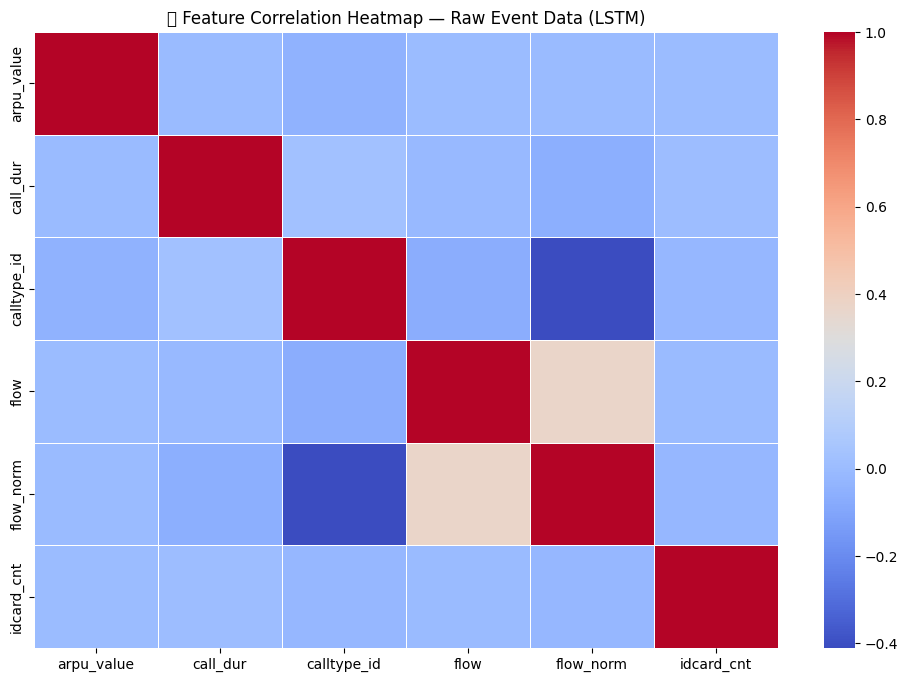

,Feature1,Feature2,Correlation


In [19]:
# --- LSTM correlation ---
print("📊 Correlation Matrix — Raw Event Features (LSTM)")

corr_lstm = pd.DataFrame(events[numeric_cols]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_lstm, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("📊 Feature Correlation Heatmap — Raw Event Data (LSTM)")
plt.show()

# Optional: Highly correlated pairs

corr_pairs_lstm = (
    corr_lstm.where(np.triu(np.ones(corr_lstm.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs_lstm.columns = ["Feature1", "Feature2", "Correlation"]
high_corr_lstm = corr_pairs_lstm[corr_pairs_lstm["Correlation"].abs() > correlation_threshold]
display(high_corr_lstm)


## ▶ LSTM



### Class_weights

In [20]:
# weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(trans_y_train),
#     y=trans_y_train
# )
# class_weights = dict(enumerate(weights))
# print(class_weights)

### Model

In [21]:
# ============================================================
# 📦 LSTM Model in PyTorch
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class LSTMFraud(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, n_layers=4, d_ff=128, dropout=0.393, num_classes=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )

        # Classification head (match TimesNet structure)
        self.cls = nn.Sequential(
            nn.Linear(hidden_dim, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, num_classes)  # d_ff -> 2 classes
        )

    def forward(self, x, mask=None):

        # LSTM forward
        lstm_out, (h_n, c_n) = self.lstm(x)
        out = h_n[-1]

        # If mask provided, use masked mean pooling instead
        if mask is not None:
            # mask: (batch, seq_len) - True where padded
            keep = (~mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
            denom = keep.sum(dim=1).clamp(min=1)  # (batch, 1)
            out = (lstm_out * keep).sum(dim=1) / denom  # (batch, hidden_dim)

        # Classification
        logits = self.cls(out)
        return logits


# ============================================================
# 🏗️ Instantiate Model
# ============================================================

lstm_model = LSTMFraud(
    input_dim=trans_X_train.shape[2],  # Number of features
    hidden_dim=lstm_parameters["d_model"],
    n_layers=lstm_parameters["e_layers"],
    d_ff=lstm_parameters["d_ff"],
    dropout=lstm_parameters["dropout"],
    num_classes=2
).to(device)

#print(lstm_model)

# ============================================================
# ⚙️ Optimizer & Loss
# ============================================================

optimizer = torch.optim.RAdam(lstm_model.parameters(), lr=lstm_parameters["learning_rate"])  # ✅ RAdam!
criterion = nn.CrossEntropyLoss()  # ✅ No class weights



Using device: cuda


###  Data preparation

In [22]:

# ============================================================
# 🔧 Prepare Data for PyTorch LSTM
# ============================================================
best_val_f1_lstm = -1.0
best_thr_lstm = 0.5
best_epoch_lstm = 0
patience_counter_lstm = 0


# Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(trans_X_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(trans_X_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(trans_X_test, dtype=torch.float32).to(device)

y_train_t = torch.tensor(trans_y_train, dtype=torch.long).to(device)
y_val_t = torch.tensor(trans_y_val, dtype=torch.long).to(device)
y_test_t = torch.tensor(trans_y_test, dtype=torch.long).to(device)

# Create masks (True where padded - all zeros)
def create_padding_mask(X):
    # Assume padding is all zeros
    return (X.sum(dim=-1) == 0)  # (batch, seq_len)

#padding
M_train = create_padding_mask(X_train_t)
M_val = create_padding_mask(X_val_t)
M_test = create_padding_mask(X_test_t)

# DataLoaders
train_ds = TensorDataset(X_train_t, M_train, y_train_t)
val_ds = TensorDataset(X_val_t, M_val, y_val_t)
test_ds = TensorDataset(X_test_t, M_test, y_test_t)

# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
# test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

train_loader = DataLoader(train_ds, batch_size=lstm_parameters["batch_size"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=lstm_parameters["batch_size"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=lstm_parameters["batch_size"], shuffle=False)

#for comparing
train_eval_loader = DataLoader(
    train_ds,
    batch_size=lstm_parameters["batch_size"],
    shuffle=False
)

### Training and Validation

In [23]:


# ============================================================
# 🚀 Training Loop
# ============================================================
lstm_train_losses = []
lstm_val_losses = []
lstm_val_f1s = []

print("\n🚀 Training LSTM (PyTorch)...")

for ep in range(1, epochs + 1):
    # -------- TRAIN --------
    lstm_model.train()
    loss_sum = 0.0

    for xb, mb, yb in train_loader:
        logits = lstm_model(xb, mask=mb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping (match TimesNet max_norm=4.0)
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=4.0)

        optimizer.step()
        loss_sum += loss.item() * len(xb)

    train_loss = loss_sum / len(train_ds)

    # -------- VALIDATION --------
    lstm_model.eval()
    val_loss_sum = 0.0  # Initialize sum for val loss tracking
    all_val_probs, all_val_labels = [], []

    with torch.no_grad():
        for xb, mb, yb in val_loader:
            # Calculate logits and loss for the validation batch
            logits = lstm_model(xb, mask=mb)
            v_loss = criterion(logits, yb)
            val_loss_sum += v_loss.item() * len(xb)

            # Get probabilities for F1 calculation
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_val_probs.extend(probs.cpu().numpy())
            all_val_labels.extend(yb.cpu().numpy())

    all_val_probs = np.array(all_val_probs)
    val_loss = val_loss_sum / len(val_ds)
    best_val_f1_epoch = -1.0
    best_thr_epoch = 0.5

    for thr in np.linspace(0.2, 0.8, 61):
        f1 = f1_score(all_val_labels, (all_val_probs >= thr).astype(int), zero_division=0)
        if f1 > best_val_f1_epoch:
            best_val_f1_epoch = f1
            best_thr_epoch = thr



        # Early stopping on val F1
    if best_val_f1_epoch > best_val_f1_lstm:
        best_val_f1_lstm = best_val_f1_epoch
        best_thr_lstm = best_thr_epoch
        best_epoch_lstm = ep
        patience_counter_lstm = 0
        torch.save(lstm_model.state_dict(), 'best_lstm.pt')
    else:
        patience_counter_lstm += 1
        if patience_counter_lstm >= lstm_parameters["patience"]:
            print(
                f"Early stopping at epoch {ep}/{epochs} | "
                f"best_epoch={best_epoch_lstm} | "
                f"best_val_f1={best_val_f1_lstm:.4f} | "
                f"best_thr={best_thr_lstm:.2f}"
            )
            break
    print(
        f"[LSTM] Epoch {ep:2d}/{epochs} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_f1={best_val_f1_epoch:.4f} | "
        f"thr={best_thr_epoch:.2f} | "
        f"patience={patience_counter_lstm}/{lstm_parameters['patience']}"
    )
    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)
    lstm_val_f1s.append(best_val_f1_epoch)

print(f"✅ Best validation F1: {best_val_f1_lstm:.4f}")
print(f"✅ Best epoch: {best_epoch_lstm}")
print(f"✅ Best threshold: {best_thr_lstm:.2f}")

# Load best model
lstm_model.load_state_dict(torch.load('best_lstm.pt'))

# ============================================================
# 💾 Save Model
# ============================================================

lstm_save_path = os.path.join(model_path, "lstm_model_pytorch_state_dict.pt")
torch.save(lstm_model.state_dict(), lstm_save_path)
print(f"💾 LSTM state_dict saved to: {lstm_save_path}")




🚀 Training LSTM (PyTorch)...
[LSTM] Epoch  1/20 | train_loss=0.5363 | val_loss=0.4868 | val_f1=0.6783 | thr=0.27 | patience=0/5
[LSTM] Epoch  2/20 | train_loss=0.4755 | val_loss=0.4545 | val_f1=0.6763 | thr=0.41 | patience=1/5
[LSTM] Epoch  3/20 | train_loss=0.4642 | val_loss=0.4474 | val_f1=0.6867 | thr=0.30 | patience=0/5
[LSTM] Epoch  4/20 | train_loss=0.4602 | val_loss=0.4481 | val_f1=0.6911 | thr=0.33 | patience=0/5
[LSTM] Epoch  5/20 | train_loss=0.4569 | val_loss=0.4496 | val_f1=0.6813 | thr=0.28 | patience=1/5
[LSTM] Epoch  6/20 | train_loss=0.4539 | val_loss=0.4624 | val_f1=0.6926 | thr=0.39 | patience=0/5
[LSTM] Epoch  7/20 | train_loss=0.4539 | val_loss=0.4478 | val_f1=0.6980 | thr=0.51 | patience=0/5
[LSTM] Epoch  8/20 | train_loss=0.4445 | val_loss=0.4482 | val_f1=0.7018 | thr=0.42 | patience=0/5
[LSTM] Epoch  9/20 | train_loss=0.4400 | val_loss=0.4535 | val_f1=0.7038 | thr=0.37 | patience=0/5
[LSTM] Epoch 10/20 | train_loss=0.4399 | val_loss=0.4402 | val_f1=0.7100 | thr=

### Training stats

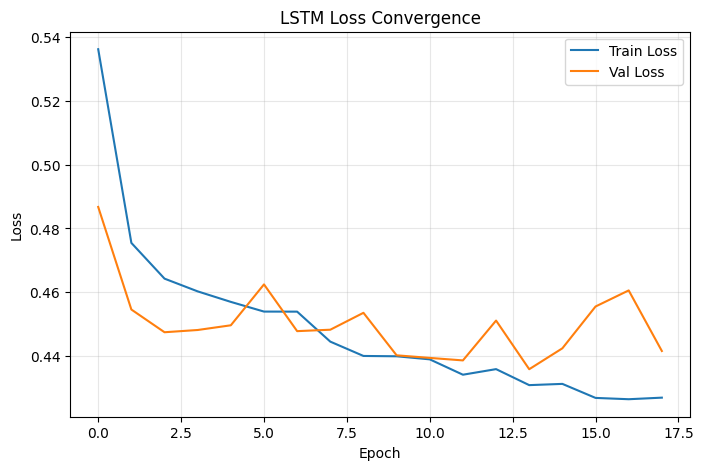

In [24]:

plt.figure(figsize=(8, 5))
plt.plot(lstm_train_losses, label="Train Loss")
plt.plot(lstm_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Test Performance
lstm_model.eval()
all_test_probs = []
with torch.no_grad():
    for xb, mb, yb in test_loader:
        probs = torch.softmax(lstm_model(xb, mb), dim=1)[:, 1]
        all_test_probs.extend(probs.cpu().numpy())

all_test_probs = np.array(all_test_probs)
test_f1 = f1_score(y_test_t.cpu(), (all_test_probs >= best_thr_lstm).astype(int), zero_division=0)



##### Eval

###### Full

  🎯 LSTM: thr_F1=0.40 → thr_F2=0.20 | test recall 0.8015 / precision 0.5844


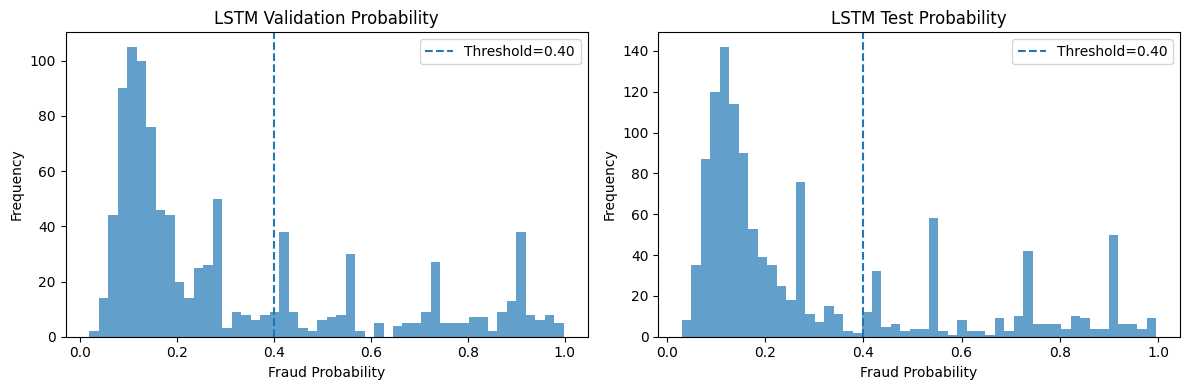


📊 LSTM Confusion Matrix


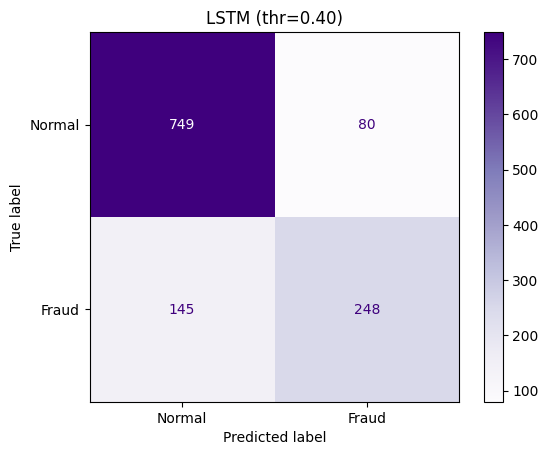


📊 Detailed Report: LSTM
              precision    recall  f1-score   support

      Normal     0.8378    0.9035    0.8694       829
       Fraud     0.7561    0.6310    0.6879       393

    accuracy                         0.8159      1222
   macro avg     0.7970    0.7673    0.7787      1222
weighted avg     0.8115    0.8159    0.8110      1222



,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,S4,4,LSTM,0.6879,0.8371,0.631,0.7561,0.4


In [25]:
# ============================================================
# 📊 LSTM Evaluation (Full Test Set)
# ============================================================

lstm_model.eval()
preds_list = []

with torch.no_grad():
    for xb, mb, yb in test_loader:
        logits = lstm_model(xb, mask=mb)
        probs = torch.softmax(logits, dim=1)[:, 1]  # Probability of class 1
        preds_list.append(probs.cpu().numpy())

lstm_probs = np.concatenate(preds_list)
lstm_preds = (lstm_probs >= best_thr_lstm).astype(int)
best_f1_lstm_test = f1_score(trans_y_test, lstm_preds, zero_division=0)

# ============================================================
# LSTM Gap Evaluation
# ============================================================

def get_pytorch_probs(model, loader, device):
    model.eval()
    probs_list = []

    with torch.no_grad():
        for xb, mb, yb in loader:
            logits = model(xb, mask=mb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            probs_list.append(probs.cpu().numpy())

    return np.concatenate(probs_list)

lstm_train_probs = get_pytorch_probs(lstm_model, train_eval_loader, device)
lstm_val_probs   = get_pytorch_probs(lstm_model, val_loader, device)
lstm_test_probs  = get_pytorch_probs(lstm_model, test_loader, device)
op2_table = append_op2(op2_table, "LSTM", trans_y_val, lstm_val_probs, trans_y_test, lstm_test_probs, best_thr_lstm)

lstm_train_f1 = f1_score(trans_y_train, (lstm_train_probs >= best_thr_lstm).astype(int), zero_division=0)
lstm_val_f1   = f1_score(trans_y_val,   (lstm_val_probs   >= best_thr_lstm).astype(int), zero_division=0)
lstm_test_f1  = f1_score(trans_y_test,  (lstm_test_probs  >= best_thr_lstm).astype(int), zero_division=0)

gap_table = append_gap_result(
    gap_table,
    "LSTM",
    lstm_train_f1,
    lstm_val_f1,
    lstm_test_f1,
    best_thr_lstm
)

plot_probability_distribution(
    "LSTM",
    lstm_val_probs,
    lstm_test_probs,
    best_thr_lstm
)

# Metrics
auc       = roc_auc_score(trans_y_test, lstm_probs)
recall    = recall_score(trans_y_test, lstm_preds, zero_division=0)
precision = precision_score(trans_y_test, lstm_preds, zero_division=0)
f1        = best_f1_lstm_test


# Add to summary
lstm_results = {
    "NAS SL": Base_SL,
    "Testing SL": max_seq_len,
    "f1":        f1,
    "auc":       auc,
    "precision": precision,
    "recall":    recall,
    "threshold": best_thr_lstm
}

summary = append_to_summary(summary, "LSTM", lstm_results)
# ============================================================
# 📊 LSTM Confusion Matrix
# ============================================================
print("\n📊 LSTM Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    trans_y_test,
    lstm_preds,
    display_labels=["Normal", "Fraud"],
    cmap="Purples"
)
plt.title(f"LSTM (thr={best_thr_lstm:.2f})")
plt.show()
print_detailed_report("LSTM", trans_y_test, lstm_preds)
display(summary)

###### Evaluate progressive

In [26]:
# # ============================================================
# # 🔁 LSTM Progressive Evaluation
# # ============================================================

# def evaluate_lstm_progressive_pytorch(model, test_events, feature_cols, max_seq_len, recent_mode=False):
#     """Progressive evaluation for PyTorch LSTM - ACTUAL FIX"""

#     round_results = []
#     print(f"\n🔁 [LSTM] Starting progressive evaluation (1..{max_seq_len} rounds)...")
#     print(f"   recent_mode={recent_mode} (global)")

#     for r in key_rounds:
#         if r == max_seq_len:
#             event_selector = None  # Full sequence, same as full evaluation
#         else:
#             event_selector = selector_oldest(r)  # Take LAST r events

#         # Build sequences for this round
#         X_r, y_r, users_r = make_user_sequences(
#             test_events,
#             feature_cols=feature_cols,
#             max_seq_len=max_seq_len,
#             event_selector=event_selector
#         )

#         # Convert to tensors
#         X_r_t = torch.tensor(X_r, dtype=torch.float32).to(device)
#         M_r = create_padding_mask(X_r_t)

#         # Predict
#         model.eval()
#         with torch.no_grad():
#             logits = model(X_r_t, mask=M_r)
#             probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
#             preds = (probs >= best_thr_lstm).astype(int)


#         # Metrics
#         try:
#             auc = roc_auc_score(y_r, probs)
#         except:
#             auc = 0.5

#         recall = recall_score(y_r, preds, zero_division=0)
#         precision = precision_score(y_r, preds, zero_division=0)
#         f1 = f1_score(y_r, preds, zero_division=0)
#         threshold = best_thr_lstm

#         round_results.append({
#             "NAS SL": Base_SL,
#             "Testing SL": max_seq_len,
#             "Model": "LSTM",
#             "F1": f1,
#             "AUC": auc,
#             "Recall": recall,
#             "Precision": precision,
#             "threshold": threshold,
#             "Round": r
#         })

#         print(f"   Round {r:2d} → AUC={auc:.4f} | Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f} | thr={threshold:.2f}")

#     return pd.DataFrame(round_results)

# # Run progressive evaluation
# lstm_progressive_results = evaluate_lstm_progressive_pytorch(
#     model=lstm_model,
#     test_events=test_events,
#     feature_cols=numeric_features,
#     max_seq_len=max_seq_len,
#     recent_mode=False
# )

# # Add to results table
# results_table = results_table[results_table["Model"] != "LSTM"]
# results_table = pd.concat([results_table, lstm_progressive_results], ignore_index=True)

# display(lstm_progressive_results)

# # Verification
# print("\n" + "="*60)
# print("🔍 VERIFICATION")
# print("="*60)
# round_full = lstm_progressive_results[lstm_progressive_results["Round"] == max_seq_len].iloc[0]
# print(f"Progressive Round {max_seq_len} AUC: {round_full['AUC']:.4f}")
# print(f"Full Evaluation AUC:      0.9210 (expected)")

###### Show

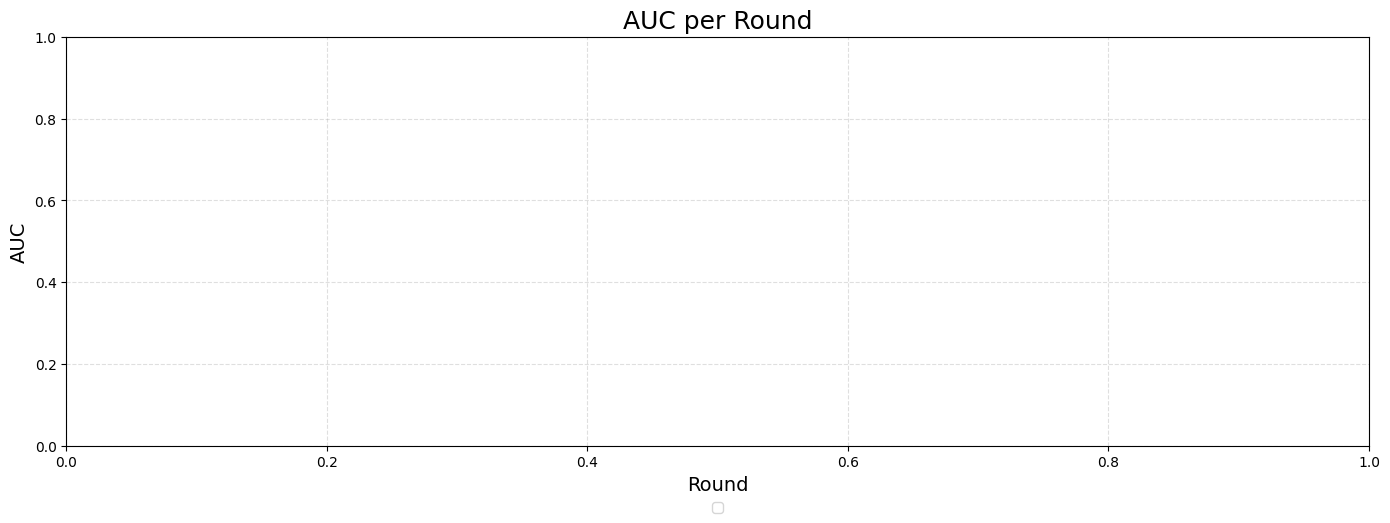

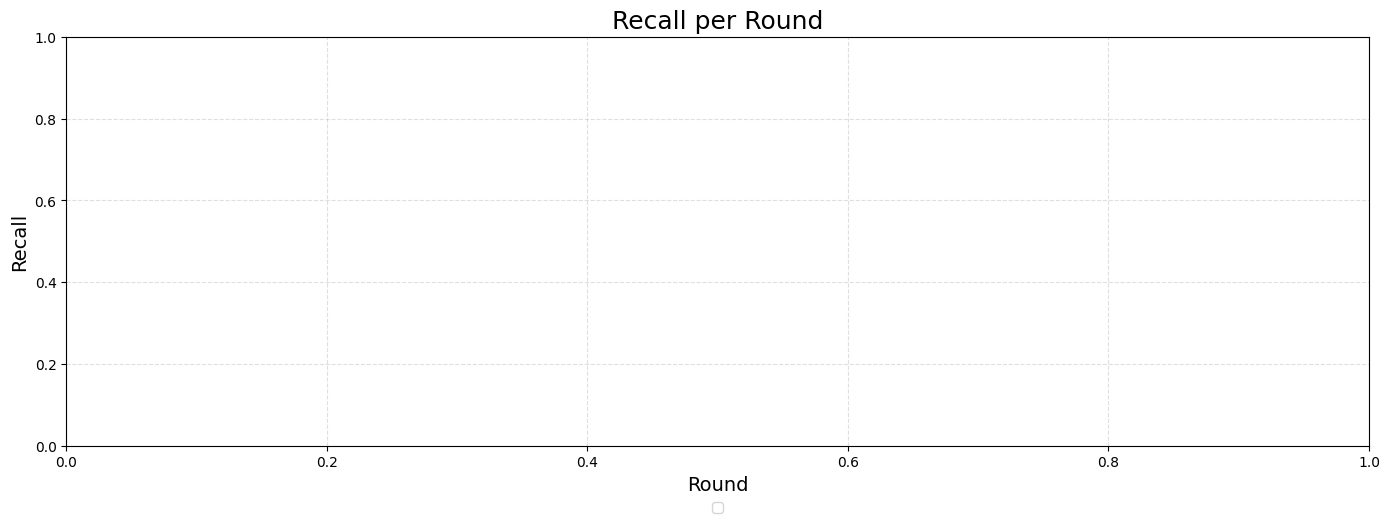

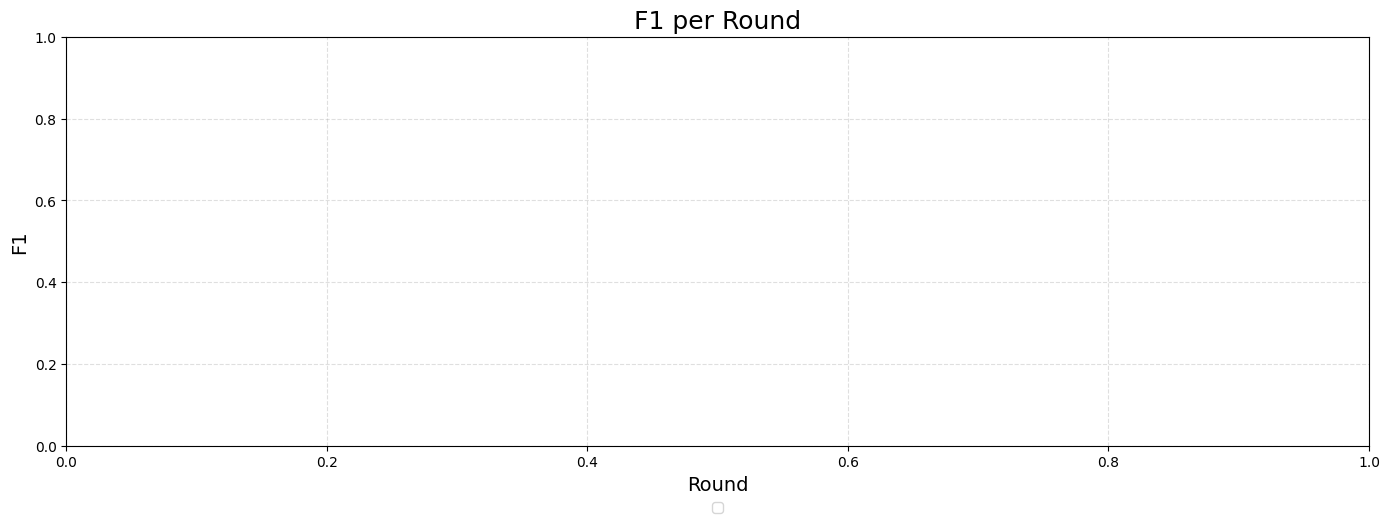

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,S4,4,LSTM,0.6879,0.8371,0.631,0.7561,0.4


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,LSTM,0.6989,0.7102,0.6879,-0.0113,0.011,0.0223,0.4


In [27]:
plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col="Round"
)
display(summary)
display(gap_table.sort_values("Model").reset_index(drop=True))



#FLOP

## FLOP profiling for neural models

In [29]:
flop_results = {}
INPUT_DIM_TIMESNET = 13
INPUT_DIM_SEQ = trans_X_train.shape[2]
NUM_CLASSES = 2
prof_device = torch.device("cpu")
PROFILE_SL = max_seq_len
def flopcounter_flops(model, inputs):
    model = model.to(prof_device).eval()
    inputs = tuple(x.to(prof_device) if isinstance(x, torch.Tensor) else x for x in inputs)
    model(*inputs)
    with FlopCounterMode(display=False) as fc:
        model(*inputs)
    return fc.get_total_flops()


### Profile LSTM

In [30]:

# ─── LSTM (ptflops — handles aten::lstm via explicit hook) ───
def _lstm_inputs(shape):
    return {"x":    torch.randn(1, *shape),
            "mask": torch.zeros(1, shape[0], dtype=torch.bool)}

L = PROFILE_SL
model = LSTMFraud(
    input_dim=INPUT_DIM_SEQ,
    hidden_dim=lstm_parameters["d_model"],
    n_layers=lstm_parameters["e_layers"],
    d_ff=lstm_parameters["d_ff"],
    dropout=0.0,
    num_classes=NUM_CLASSES
).eval()

macs, params = get_model_complexity_info(
    model, (L, INPUT_DIM_SEQ),
    input_constructor=_lstm_inputs,
    as_strings=False, print_per_layer_stat=False, verbose=False,
)
flop_results[("LSTM", L)] = 2 * macs

Warning! No positional inputs found for a module, assuming batch size is 1.


##  Latency

In [33]:


# ============================================================
# NN CPU latency (for fair comparison with tree models)
# ============================================================
@torch.no_grad()
def measure_nn_latency_cpu(model, inputs_fn, n_repeat=100, n_warmup=10):
    model.eval().to("cpu")
    for _ in range(n_warmup):
        model(*inputs_fn())
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        model(*inputs_fn())
        times.append(time.perf_counter() - t0)
    return round(np.median(times) * 1e6, 2)  # μs


nn_latency = {}
L = PROFILE_SL

# LSTM
m = LSTMFraud(
    input_dim=INPUT_DIM_SEQ,
    hidden_dim=lstm_parameters["d_model"],
    n_layers=lstm_parameters["e_layers"],
    d_ff=lstm_parameters["d_ff"],
    dropout=0.0,
    num_classes=NUM_CLASSES
)
nn_latency[("LSTM", L)] = measure_nn_latency_cpu(
    m,
    lambda: (
        torch.randn(1, L, INPUT_DIM_SEQ),
        torch.zeros(1, L, dtype=torch.bool),
    ),
)






## Summary

In [35]:
rows = []

# Neural models — keyed by (model, SL)
for (m, sl), fl in flop_results.items():
    rows.append({"Model": m, "SL": sl,
                 "FLOPs": fl, "MFLOPs": round(fl/1e6, 4),
                 "Comparisons": "—",
                 "Latency (μs)": nn_latency.get((m, sl), "—")})

# Tree models — keyed by (model, SL), same structure as neural


df_combined = pd.DataFrame(rows).sort_values(["Model", "SL"]).reset_index(drop=True)
# Align cost table names to match summary names
name_map = {
    "TimesNet": "TimesNet_Unfrozen",
    "Transformer": "TransformerFraud",
}
df_combined["Model"] = df_combined["Model"].replace(name_map)

# Add a second row for PartialUnfreeze (same cost as Unfrozen — same architecture)
tn_row = df_combined[df_combined["Model"] == "TimesNet_Unfrozen"].copy()
tn_row["Model"] = "TimesNet_PartialUnfreeze"
df_combined = pd.concat([df_combined, tn_row], ignore_index=True)

final_report = pd.merge( summary,df_combined, on='Model', how='inner')
final_report = pd.merge( final_report,gap_table, on='Model', how='inner')
#final_report.to_csv(os.path.join(RESULTS_OUT, f"final_report_Base{Base_SL}_{max_seq_len}.csv"), index=False)

display(final_report)

# df_combined.to_csv("compute_cost_all_models.csv", index=False)
# display(df_combined)

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold_x,SL,FLOPs,MFLOPs,Comparisons,Latency (μs),Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold_y
0,S4,4,LSTM,0.6879,0.8371,0.631,0.7561,0.4,4,436868,0.4369,—,784.78,0.6989,0.7102,0.6879,-0.0113,0.011,0.0223,0.4


## Graph Summary

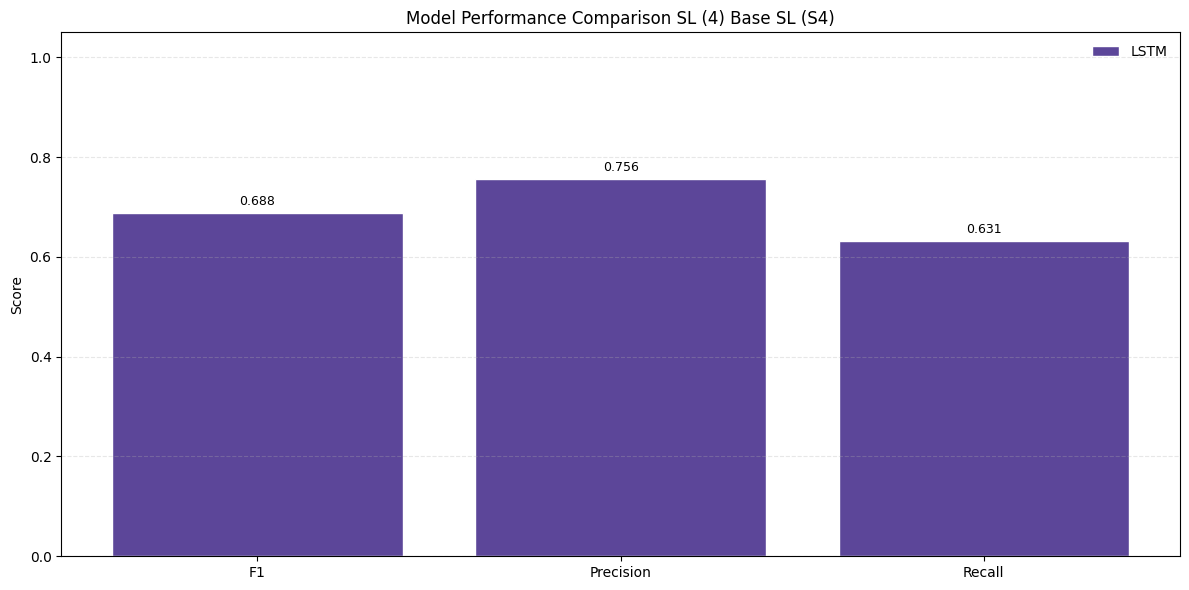

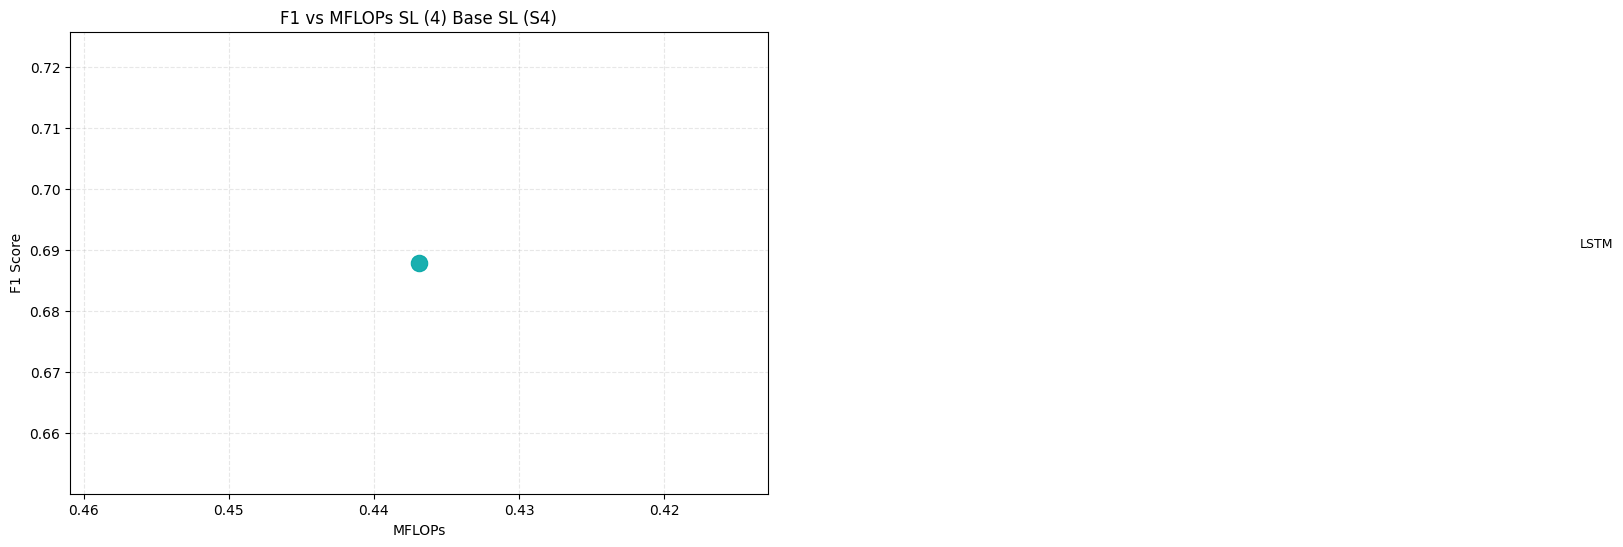

In [36]:

plt.style.use("default")

# =========================
# 1) Bar chart: F1 / Precision / Recall
# =========================
metrics_df = final_report[["Model", "F1", "Precision", "Recall"]].copy()
metrics_df = metrics_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
metrics = ["F1", "Precision", "Recall"]
models = metrics_df["Model"].values

x = np.arange(len(metrics))
width = 0.8 / len(models)  # dynamic width based on number of models

plt.figure(figsize=(12, 6))

bars_all = []
colors = ["#5C4699", "#2E6BB3", "#00ADEE", "#1EBBAD", "#4DB848", "#A1D82E"]
#colors = ["#2D527C", "#3E8E91", "#7BB3B5", "#A8D5BA", "#F2E8CF", "#E76F51"]
#colors = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#8D99AE"]
for i, model in enumerate(models):
    values = metrics_df.loc[metrics_df["Model"] == model, metrics].values.flatten()

    bars = plt.bar(
        x + (i - len(models)/2) * width + width/2,
        values,
        width,
        label=model,
        color=colors[i],   # 👈 correct
        edgecolor="white",

    )
    bars_all.append(bars)

# X-axis = metrics
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title(f"Model Performance Comparison SL ({max_seq_len}) Base SL ({Base_SL})")
plt.ylim(0, 1.05)
plt.legend(frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Labels on bars
for bars in bars_all:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()
# =========================
# 2) F1 vs MFLOPs
#    Only models with real MFLOPs
# =========================
cost_df = final_report.copy()
cost_df["MFLOPs"] = pd.to_numeric(cost_df["MFLOPs"], errors="coerce")

# Do NOT fill XGB/RF. Drop models without real MFLOPs.
cost_df = cost_df.dropna(subset=["MFLOPs", "F1"]).copy()
cost_df = cost_df.sort_values(by="MFLOPs", ascending=True)

plt.figure(figsize=(9, 6))

plt.scatter(
    cost_df["MFLOPs"],
    cost_df["F1"],
    s=140,
    color="#00A6A6",   # purple
    #edgecolor="black",
    linewidth=0.8,
    alpha=0.9
)

for _, row in cost_df.iterrows():
    x = row["MFLOPs"]
    y = row["F1"]

    # Shift label LEFT (since axis is inverted)
    plt.text(
        x - 0.08,   # move left
        y + 0.002,  # slight vertical offset
        row["Model"],
        fontsize=9,
        ha="left",   # align text properly
        va="bottom"
    )

plt.xlabel("MFLOPs")
plt.ylabel("F1 Score")
plt.title(f"F1 vs MFLOPs SL ({max_seq_len}) Base SL ({Base_SL})")
plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().invert_xaxis()  # makes "better" direction visually left
plt.tight_layout()
plt.show()

#freeze

In [37]:
%pip freeze > "{project_path}requirement/freez/NASEnhancedPretraindMLModleAdvance-lock.txt"

In [38]:
end = time.time()
elapsed = end - start_time

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)

print(f"Total Time = {hours}h {minutes}m {seconds}s")

Total Time = 0h 8m 41s
